# Frequencia_Cor — Comparação de Classificadores
Reutiliza as features salvas em cache (`cache_freq_cor_v1/`) para testar múltiplos algoritmos.

**Features:** 35 dimensões (PCA invariante, PCA escalar, RGB, HSV, FFT)  
**Labels:** 0 = Real | 1 = IA

## Bloco 1 — Imports

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time
from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, brier_score_loss,
    confusion_matrix, classification_report, roc_curve, precision_recall_curve
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    AdaBoostClassifier, ExtraTreesClassifier
)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')
print('imports OK')

## Bloco 2 — Carregar Features do Cache

In [17]:
# detecta raiz do projeto
_here = Path('.').resolve()
PROJECT_ROOT = _here
while not (PROJECT_ROOT / '.git').exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

CACHE_DIR = PROJECT_ROOT / 'cache_freq_cor_v1'

print('arquivos no cache:')
for f in sorted(CACHE_DIR.glob('*.npy')):
    data = np.load(f)
    print(f'   {f.name}: shape={data.shape}, dtype={data.dtype}')

X_train = np.load(CACHE_DIR / 'train_X.npy')
y_train = np.load(CACHE_DIR / 'train_y.npy')
X_test  = np.load(CACHE_DIR / 'test_X.npy')
y_test  = np.load(CACHE_DIR / 'test_y.npy')

print(f'\ntrain: {X_train.shape} | test: {X_test.shape}')
print(f'train — Real: {(y_train==0).sum():,} | Fake: {(y_train==1).sum():,}')
print(f'test  — Real: {(y_test==0).sum():,}  | Fake: {(y_test==1).sum():,}')

arquivos no cache:
   test_X.npy: shape=(12000, 35), dtype=float32
   test_y.npy: shape=(12000,), dtype=int8
   train_X.npy: shape=(96000, 35), dtype=float32
   train_y.npy: shape=(96000,), dtype=int8

train: (96000, 35) | test: (12000, 35)
train — Real: 48,000 | Fake: 48,000
test  — Real: 6,000  | Fake: 6,000


## Bloco 3 — Normalização

In [ ]:
# split 80/20 do treino — val usado para calibração e threshold
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.20, stratify=y_train, random_state=42
)

scaler    = StandardScaler()
X_tr_s    = scaler.fit_transform(X_tr)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

print(f'treino: {X_tr.shape[0]:,} | val: {X_val.shape[0]:,} | teste: {X_test.shape[0]:,}')
print(f'NaN — tr: {np.isnan(X_tr_s).sum()} | val: {np.isnan(X_val_s).sum()} | test: {np.isnan(X_test_s).sum()}')

## Bloco 4 — Definição dos Classificadores

In [19]:
n_real   = (y_train == 0).sum()
n_fake   = (y_train == 1).sum()
scale_pw = n_real / n_fake

CLASSIFICADORES = {
    'XGBoost': XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=scale_pw,
        eval_metric='auc', random_state=42, n_jobs=-1, verbosity=0
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=300, max_depth=None, class_weight='balanced',
        random_state=42, n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=200, max_depth=5, learning_rate=0.05,
        subsample=0.8, random_state=42
    ),
    'Extra Trees': ExtraTreesClassifier(
        n_estimators=300, class_weight='balanced',
        random_state=42, n_jobs=-1
    ),
    'SVM (RBF)': SVC(
        kernel='rbf', C=1.0, gamma='scale',
        class_weight='balanced', probability=True, random_state=42
    ),
    'Logistic Regression': LogisticRegression(
        C=1.0, class_weight='balanced', max_iter=1000,
        solver='lbfgs', random_state=42, n_jobs=-1
    ),
    'MLP (Neural Net)': MLPClassifier(
        hidden_layer_sizes=(256, 128, 64), activation='relu',
        max_iter=300, early_stopping=True, validation_fraction=0.1,
        random_state=42
    ),
    'AdaBoost': AdaBoostClassifier(
        n_estimators=200, learning_rate=0.1, random_state=42
    ),
    'KNN (k=7)': KNeighborsClassifier(
        n_neighbors=7, weights='distance', n_jobs=-1
    ),
    'Decision Tree': DecisionTreeClassifier(
        max_depth=10, class_weight='balanced', random_state=42
    ),
    'Naive Bayes': GaussianNB(),
}

print(f'{len(CLASSIFICADORES)} classificadores definidos')
for nome in CLASSIFICADORES:
    print(f'   • {nome}')

11 classificadores definidos
   • XGBoost
   • Random Forest
   • Gradient Boosting
   • Extra Trees
   • SVM (RBF)
   • Logistic Regression
   • MLP (Neural Net)
   • AdaBoost
   • KNN (k=7)
   • Decision Tree
   • Naive Bayes


## Bloco 5 — Treinamento e Avaliação

In [ ]:
resultados = []

for nome, clf in CLASSIFICADORES.items():
    print(f'treinando {nome}...')
    t0 = time.time()

    clf.fit(X_tr_s, y_tr)
    y_pred = clf.predict(X_test_s)

    if hasattr(clf, 'predict_proba'):
        y_proba = clf.predict_proba(X_test_s)[:, 1]
    elif hasattr(clf, 'decision_function'):
        y_proba = clf.decision_function(X_test_s)
    else:
        y_proba = y_pred.astype(float)

    acc   = accuracy_score(y_test, y_pred)
    f1    = f1_score(y_test, y_pred)
    auc   = roc_auc_score(y_test, y_proba)
    tempo = time.time() - t0

    resultados.append({
        'nome': nome, 'clf': clf,
        'y_pred': y_pred, 'y_proba': y_proba,
        'accuracy': acc, 'f1': f1, 'auc': auc, 'tempo': tempo
    })
    print(f'   Acc={acc:.4f} | F1={f1:.4f} | AUC={auc:.4f} | {tempo:.1f}s')

resultados.sort(key=lambda x: x['accuracy'], reverse=True)

print('\n' + '='*65)
print(f'{"Classificador":<22} {"Accuracy":>10} {"F1":>8} {"AUC-ROC":>10} {"Tempo":>8}')
print('='*65)
for r in resultados:
    print(f"{r['nome']:<22} {r['accuracy']:>10.4f} {r['f1']:>8.4f} {r['auc']:>10.4f} {r['tempo']:>7.1f}s")
print('='*65)

## Bloco 6 — Matrizes de Confusão (todos os classificadores)

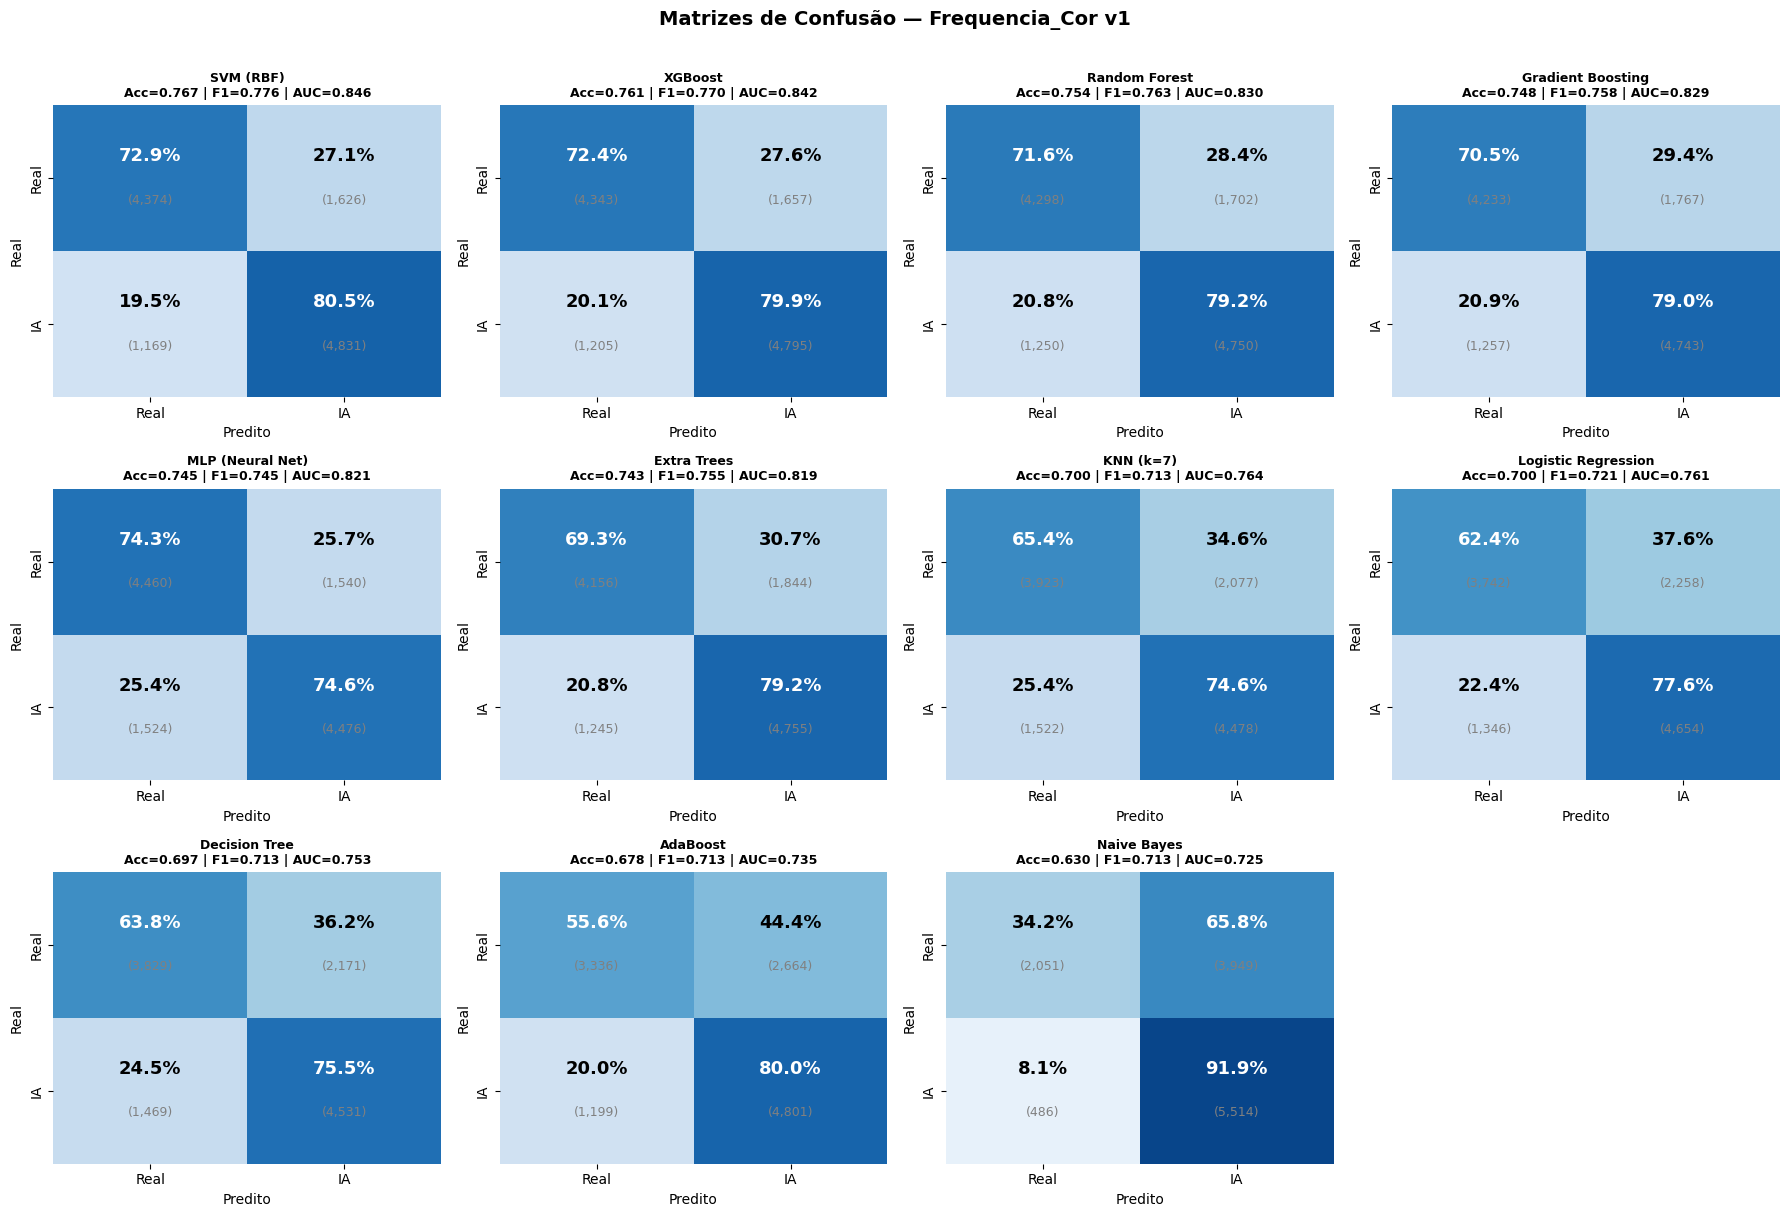

salvo: comparacao_matrizes_confusao_freq_cor.png


In [ ]:
n_clf = len(resultados)
cols  = 4
rows  = (n_clf + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(cols * 4.5, rows * 4))
axes_flat = axes.flatten()

for idx, r in enumerate(resultados):
    ax     = axes_flat[idx]
    cm     = confusion_matrix(y_test, r['y_pred'])
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

    sns.heatmap(
        cm_pct, annot=False, fmt='.1f', cmap='Blues', ax=ax,
        xticklabels=['Real', 'IA'], yticklabels=['Real', 'IA'],
        vmin=0, vmax=100, cbar=False
    )
    for i in range(2):
        for j in range(2):
            cor = 'white' if cm_pct[i, j] > 50 else 'black'
            ax.text(j + 0.5, i + 0.35, f'{cm_pct[i,j]:.1f}%',
                    ha='center', va='center', fontsize=13, fontweight='bold', color=cor)
            ax.text(j + 0.5, i + 0.65, f'({cm[i,j]:,})',
                    ha='center', va='center', fontsize=9, color='gray')

    ax.set_title(
        f"{r['nome']}\nAcc={r['accuracy']:.3f} | F1={r['f1']:.3f} | AUC={r['auc']:.3f}",
        fontsize=9, fontweight='bold'
    )
    ax.set_ylabel('Real'); ax.set_xlabel('Predito')

for idx in range(n_clf, len(axes_flat)):
    axes_flat[idx].set_visible(False)

plt.suptitle('Matrizes de Confusão — Frequencia_Cor v1', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('comparacao_matrizes_confusao_freq_cor.png', dpi=120, bbox_inches='tight')
plt.show()
print('salvo: comparacao_matrizes_confusao_freq_cor.png')

## Bloco 7 — Gráfico de Ranking

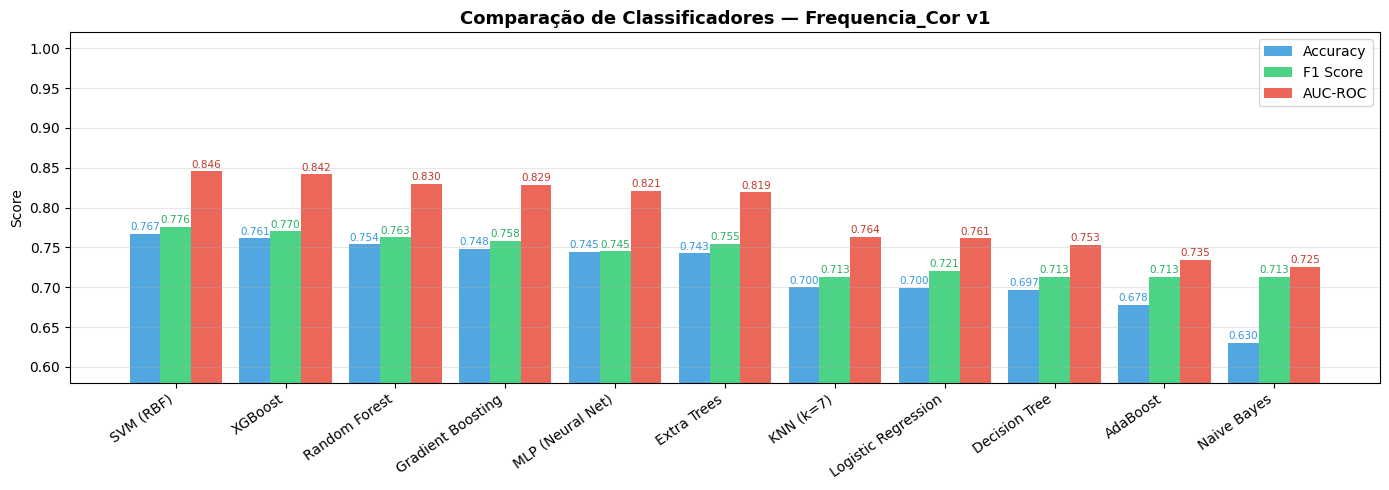

salvo: comparacao_ranking_freq_cor.png


In [ ]:
nomes = [r['nome']     for r in resultados]
accs  = [r['accuracy'] for r in resultados]
f1s   = [r['f1']       for r in resultados]
aucs  = [r['auc']      for r in resultados]

x = np.arange(len(nomes))
w = 0.28

fig, ax = plt.subplots(figsize=(14, 5))
bars1 = ax.bar(x - w, accs, w, label='Accuracy', color='#3498db', alpha=0.85)
bars2 = ax.bar(x,     f1s,  w, label='F1 Score', color='#2ecc71', alpha=0.85)
bars3 = ax.bar(x + w, aucs, w, label='AUC-ROC',  color='#e74c3c', alpha=0.85)

for bar, cor in [(bars1, '#3498db'), (bars2, '#27ae60'), (bars3, '#c0392b')]:
    for b in bar:
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.002,
                f'{b.get_height():.3f}', ha='center', va='bottom', fontsize=7.5, color=cor)

ax.set_xticks(x)
ax.set_xticklabels(nomes, rotation=35, ha='right', fontsize=10)
ax.set_ylim(min(min(accs), min(f1s), min(aucs)) - 0.05, 1.02)
ax.set_ylabel('Score')
ax.set_title('Comparação de Classificadores — Frequencia_Cor v1', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
ax.axhline(0.5, color='gray', linestyle='--', alpha=0.4, linewidth=0.8)

plt.tight_layout()
plt.savefig('comparacao_ranking_freq_cor.png', dpi=120, bbox_inches='tight')
plt.show()
print('salvo: comparacao_ranking_freq_cor.png')

## Bloco 8 — Relatório do Melhor Classificador

In [ ]:
melhor     = resultados[0]
best_clf   = melhor['clf']
best_nome  = melhor['nome']

print(f'melhor: {best_nome}  (Acc={melhor["accuracy"]:.4f} | AUC={melhor["auc"]:.4f})')

# calibração isotônica no val
proba_val_raw  = best_clf.predict_proba(X_val_s)[:, 1]
proba_test_raw = best_clf.predict_proba(X_test_s)[:, 1]

calibrator = IsotonicRegression(out_of_bounds='clip')
calibrator.fit(proba_val_raw, y_val)

proba_test_cal = calibrator.predict(proba_test_raw)
brier_antes  = brier_score_loss(y_test, proba_test_raw)
brier_depois = brier_score_loss(y_test, proba_test_cal)
print(f'   Brier antes : {brier_antes:.4f}')
print(f'   Brier depois: {brier_depois:.4f} ({"melhorou" if brier_depois < brier_antes else "piorou"})')

# limiar ótimo por F1 no val (igual à luminância v3)
proba_val_cal         = calibrator.predict(proba_val_raw)
prec, rec, thresholds = precision_recall_curve(y_val, proba_val_cal)
f1_scores             = 2 * prec[:-1] * rec[:-1] / (prec[:-1] + rec[:-1] + 1e-12)
best_idx              = int(np.argmax(f1_scores))
best_thr              = float(thresholds[best_idx])

print(f'\n   Limiar padrão (0.50): F1 = {f1_score(y_test, (proba_test_cal >= 0.50).astype(int)):.4f}')
print(f'   Limiar ótimo  ({best_thr:.2f}): F1 = {f1_score(y_test, (proba_test_cal >= best_thr).astype(int)):.4f}')

y_pred_final = (proba_test_cal >= best_thr).astype(int)
acc = accuracy_score(y_test, y_pred_final)
f1  = f1_score(y_test, y_pred_final)
auc = roc_auc_score(y_test, proba_test_cal)
cm  = confusion_matrix(y_test, y_pred_final)
tn, fp, fn, tp = cm.ravel()

sep = '=' * 55
print(f'\n{sep}')
print(f'  RELATÓRIO FINAL — Frequencia_Cor v1')
print(f'  Classificador : {best_nome}')
print(sep)
print(f'  {"Accuracy":<22}: {acc:.4f}')
print(f'  {"F1 Score":<22}: {f1:.4f}')
print(f'  {"AUC-ROC":<22}: {auc:.4f}')
print(f'  {"Brier (antes cal.)":<22}: {brier_antes:.4f}')
print(f'  {"Brier (depois cal.)":<22}: {brier_depois:.4f}')
print(f'  {"Threshold (F1 ótimo)":<22}: {best_thr:.4f}')
print(sep)
print(f'  {"FP  Real → IA":<22}: {fp:,} ({fp/(tn+fp)*100:.1f}%)')
print(f'  {"FN  IA  → Real":<22}: {fn:,} ({fn/(fn+tp)*100:.1f}%)')
print(sep)
print()
print(classification_report(y_test, y_pred_final, target_names=['Real', 'IA']))

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
sns.heatmap(cm_pct, annot=False, cmap='Blues', ax=axes[0],
            xticklabels=['Real', 'IA'], yticklabels=['Real', 'IA'],
            vmin=0, vmax=100, cbar_kws={'label': '%'})
for i in range(2):
    for j in range(2):
        cor = 'white' if cm_pct[i, j] > 50 else 'black'
        axes[0].text(j+0.5, i+0.35, f'{cm_pct[i,j]:.1f}%',
                     ha='center', va='center', fontsize=14, fontweight='bold', color=cor)
        axes[0].text(j+0.5, i+0.65, f'({cm[i,j]:,})',
                     ha='center', va='center', fontsize=10, color='gray')
axes[0].set_title(f'Matriz de Confusão\nACC={acc:.4f} | AUC={auc:.4f}', fontweight='bold')
axes[0].set_ylabel('Real'); axes[0].set_xlabel('Predito')

fpr, tpr, _ = roc_curve(y_test, proba_test_cal)
axes[1].plot(fpr, tpr, color='#9b59b6', linewidth=2, label=f'AUC={auc:.4f}')
axes[1].plot([0,1],[0,1], 'k--', alpha=0.4)
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].set_title('Curva ROC', fontweight='bold')
axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].hist(proba_test_cal[y_test==0], bins=50, alpha=0.7, color='#2ecc71', label='Real', density=True)
axes[2].hist(proba_test_cal[y_test==1], bins=50, alpha=0.7, color='#e74c3c', label='IA',   density=True)
axes[2].axvline(best_thr, color='black', linestyle='--', label=f'thr={best_thr:.3f}')
axes[2].set_xlabel('P(IA) calibrada'); axes[2].set_ylabel('Densidade')
axes[2].set_title('Distribuição de Probabilidades', fontweight='bold')
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.suptitle(f'Frequencia_Cor v1 — {best_nome} (calibrado)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('relatorio_final_freq_cor.png', dpi=120, bbox_inches='tight')
plt.show()

## Bloco 9 — Tabela Resumo Final

In [ ]:
print('\n' + '='*72)
print(f'{"#":>3}  {"Classificador":<22} {"Accuracy":>10} {"F1":>8} {"AUC-ROC":>10} {"Tempo":>8}')
print('='*72)
for i, r in enumerate(resultados, 1):
    medal = ['1o', '2o', '3o'][i-1] if i <= 3 else f'#{i}'
    print(f'{medal:>4} {r["nome"]:<22} {r["accuracy"]:>10.4f} {r["f1"]:>8.4f} {r["auc"]:>10.4f} {r["tempo"]:>7.1f}s')
print('='*72)
print(f'\n{len(resultados)} classificadores testados no conjunto de teste.')


  #  Classificador            Accuracy       F1    AUC-ROC    Tempo
  1o SVM (RBF)                  0.7671   0.7756     0.8458  5613.6s
  2o XGBoost                    0.7615   0.7702     0.8418     5.9s
  3o Random Forest              0.7540   0.7629     0.8302    48.2s
  #4 Gradient Boosting          0.7480   0.7583     0.8286   311.7s
  #5 MLP (Neural Net)           0.7447   0.7450     0.8209   268.2s
  #6 Extra Trees                0.7426   0.7548     0.8193    14.7s
  #7 KNN (k=7)                  0.7001   0.7133     0.7636    10.6s
  #8 Logistic Regression        0.6997   0.7209     0.7614     2.2s
  #9 Decision Tree              0.6967   0.7134     0.7533     4.2s
 #10 AdaBoost                   0.6781   0.7131     0.7348   100.0s
 #11 Naive Bayes                0.6304   0.7132     0.7253     0.1s

11 classificadores testados no conjunto de teste.
